In [1]:
import numpy as np
import scipy as sp
import os
from scipy.special import expit
from scipy.stats import norm
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle as pkl
from estimate_SB import _gibbs_one_iter, schbridge, sinkhorn, cost_matrix
from SB_scheme_Entropy import entropy_SB_scheme_sinkhorn
from matplotlib.animation import FuncAnimation
import time


In [2]:
import matplotlib as mpl

mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['xtick.labelsize'] = 30
mpl.rcParams['ytick.labelsize'] = 30
mpl.rcParams["axes.labelsize"] = 30
mpl.rcParams['legend.fontsize'] = 30
mpl.rcParams['axes.titlesize'] = 30
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [3]:
# helper functions for making plots and calculating deterministic variances

def draw_gaussian(mean, std_dev):
    # Generate data points for the x-axis
    x = np.linspace(mean - 3*std_dev, mean + 3*std_dev, 1000)

    # Compute the probability density function (PDF) for each data point
    pdf_values = norm.pdf(x, mean, std_dev)

    return x, pdf_values

def forward_SB_var(sigma_squared, eps, k=1):

    new_sigma_squared = ((2 - (sigma_squared/(np.sqrt((sigma_squared**2) + (eps**2)/4) + eps/2)))**2)*sigma_squared

    if k==1:
        return new_sigma_squared
    elif k==0:
        return sigma_squared
    else:
        return forward_SB_var(new_sigma_squared, eps, k=k-1)

def reverse_SB_var(sigma_squared, eps, k=1):

    new_sigma_squared = ((sigma_squared/(np.sqrt((sigma_squared**2) + (eps**2)/4) + eps/2))**2)*sigma_squared

    if k==1:
        return new_sigma_squared
    elif k==0:
        return sigma_squared
    else:
        return reverse_SB_var(new_sigma_squared, eps, k=k-1)

def draw_gaussian_mix(mu1=-2, mu2=2, std_dev=1):
    # Generate data points for the x-axis

    x = np.linspace(mu1 - 3*std_dev, mu2 + 3*std_dev, 1000)
    # Compute the probability density function (PDF) for each data point
    pdf_values = 0.5*norm.pdf(x, mu1, std_dev) + 0.5*norm.pdf(x, mu2, std_dev)

    return x, pdf_values


In [4]:
dt = 0.1
T = 5
steps = np.arange(1, 6)*10
total_steps = steps[-1]
precision=1e-8
maxiter=1e6

In [5]:
def sinkformer(T, dt, n, d, A, V, x0, checkpoints=None):

    num_steps = int(T/dt)+1

    if checkpoints is not None:
        num_checkpoints = len(checkpoints)
    else:
        num_checkpoints = num_steps
        checkpoints = np.arange(num_steps)

    x = np.zeros(shape=(num_checkpoints, n, d))
    self_attn_mat = np.zeros(shape=(num_checkpoints, n, n))
    spectrum = np.zeros(shape=(num_checkpoints, n))
    
    xnow = x0
    checks_count = 0

    for i in tqdm(range(num_steps)):

        cost_mat = cost_matrix(xnow, xnow)
        _, avg_plan, _ = sinkhorn(cost_mat, np.ones(n)/n, np.ones(n)/n, epsilon=1.0, precision=precision, maxiter=maxiter)
        eigenvalues, _ = np.linalg.eig(avg_plan)

        if i in checkpoints:
            x[checks_count, :, :] = xnow
            self_attn_mat[checks_count, :, :] = avg_plan
            spectrum[checks_count, :] = np.sort(eigenvalues)[::-1]
            checks_count += 1
        
        bar_proj = n*np.matmul(avg_plan, np.matmul(xnow, V.T))
        xnow = xnow + dt*bar_proj

    return x, self_attn_mat, spectrum
    

In [6]:
def sinkformer_bandwidth(T, dt, n, d, A, V, x0, checkpoints=None):

    num_steps = int(T/dt)+1

    if checkpoints is not None:
        num_checkpoints = len(checkpoints)
    else:
        num_checkpoints = num_steps
        checkpoints = np.arange(num_steps)

    x = np.zeros(shape=(num_checkpoints, n, d))
    self_attn_mat = np.zeros(shape=(num_checkpoints, n, n))
    spectrum = np.zeros(shape=(num_checkpoints, n))
    
    xnow = x0
    checks_count = 0

    for i in tqdm(range(num_steps)):

        cost_mat = cost_matrix(xnow, xnow)
        _, avg_plan, _ = sinkhorn(cost_mat, np.ones(n)/n, np.ones(n)/n, epsilon=dt, precision=precision, maxiter=maxiter)
        eigenvalues, _ = np.linalg.eig(avg_plan)

        if i in checkpoints:
            x[checks_count, :, :] = xnow
            self_attn_mat[checks_count, :, :] = avg_plan
            spectrum[checks_count, :] = np.sort(eigenvalues)[::-1]
            checks_count += 1
        
        bar_proj = n*np.matmul(avg_plan, np.matmul(xnow, V.T))
        xnow = xnow + (bar_proj - np.matmul(xnow, V.T))

    return x, self_attn_mat, spectrum
    

In [8]:
def get_dynamics(znow, attention, V):
    """
    - Returns: the dynamics z'(t) = (z_1'(t), ... , z_n'(t)) at some time-step t.
    """
    n = attention.shape[0]
    dlst = n * np.matmul(attention, np.matmul(znow, V.T)) - np.matmul(znow, V.T)
    # dlst = n * np.array([attention[i][j]*np.matmul(V, z_curr[j]-z_curr[i]) for j in range(n)])
    return dlst

def sinkformer_normalized(T, dt, n, d, A, V, x0, checkpoints=None):
    """
    - Returns: the evolution of z = (z_1, ..., z_n) over time.
    """
    
    num_steps = int(T/dt)+1

    if checkpoints is not None:
        num_checkpoints = len(checkpoints)
    else:
        num_checkpoints = num_steps
        checkpoints = np.arange(num_steps)

    z = np.zeros(shape=(num_checkpoints, n, d))
    self_attn_mat = np.zeros(shape=(num_checkpoints, n, n))
    spectrum = np.zeros(shape=(num_checkpoints, n))

    znow = x0
    checks_count = 0
    integration_time = np.linspace(0, T, num_steps)

    for i, t in tqdm(enumerate(integration_time)):

        # Attention matrix
        cost_mat = np.array([[np.linalg.norm(np.matmul(np.matmul(A, sp.linalg.expm(V*t)), znow[i]) - np.matmul(np.matmul(A, sp.linalg.expm(V*t)), znow[j]))**2 for j in range(n)] for i in range(n)])
        _, attention, _ = sinkhorn(cost_mat, np.ones(n)/n, np.ones(n)/n, epsilon=1.0)
        eigenvalues, _ = np.linalg.eig(attention)

        if i in checkpoints:
            z[checks_count, :, :] = znow
            self_attn_mat[checks_count, :, :] = attention
            spectrum[checks_count, :] = np.sort(eigenvalues)[::-1]
            checks_count += 1
                    
        k1 = dt * get_dynamics(znow, attention, V)
        k2 = dt * get_dynamics(znow + k1 / 2, attention, V)
        k3 = dt * get_dynamics(znow + k2 / 2, attention, V)
        k4 = dt * get_dynamics(znow + k3, attention, V)
        znow = znow + (k1 + 2*k2 + 2*k3 + k4) / 6
        # znow = znow + k1

    return z, self_attn_mat, spectrum

#### $Q^\top K = I_d$ and $V=I_d$

$$x_i^{k+1} = x_k^k + \varepsilon \sum_{j=1}^n K^\infty_{ij} x_j^k$$

In [9]:
n, d = 40, 2
A, V = np.eye(d), np.eye(d)
mu1, mu2 = 0, 0
x0 = np.concatenate((np.random.multivariate_normal(mu1*np.ones(d), np.eye(d), n//2), np.random.multivariate_normal(mu2*np.ones(d), np.eye(d), n//2)))
x, self_attn_mat, spectrum = sinkformer(T, dt, n, d, A, V, x0, checkpoints=None)

 76%|███████▋  | 39/51 [00:03<00:00, 19.54it/s]/tmp/ipykernel_2595038/1461635098.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  spectrum[checks_count, :] = np.sort(eigenvalues)[::-1]
100%|██████████| 51/51 [00:03<00:00, 16.07it/s]


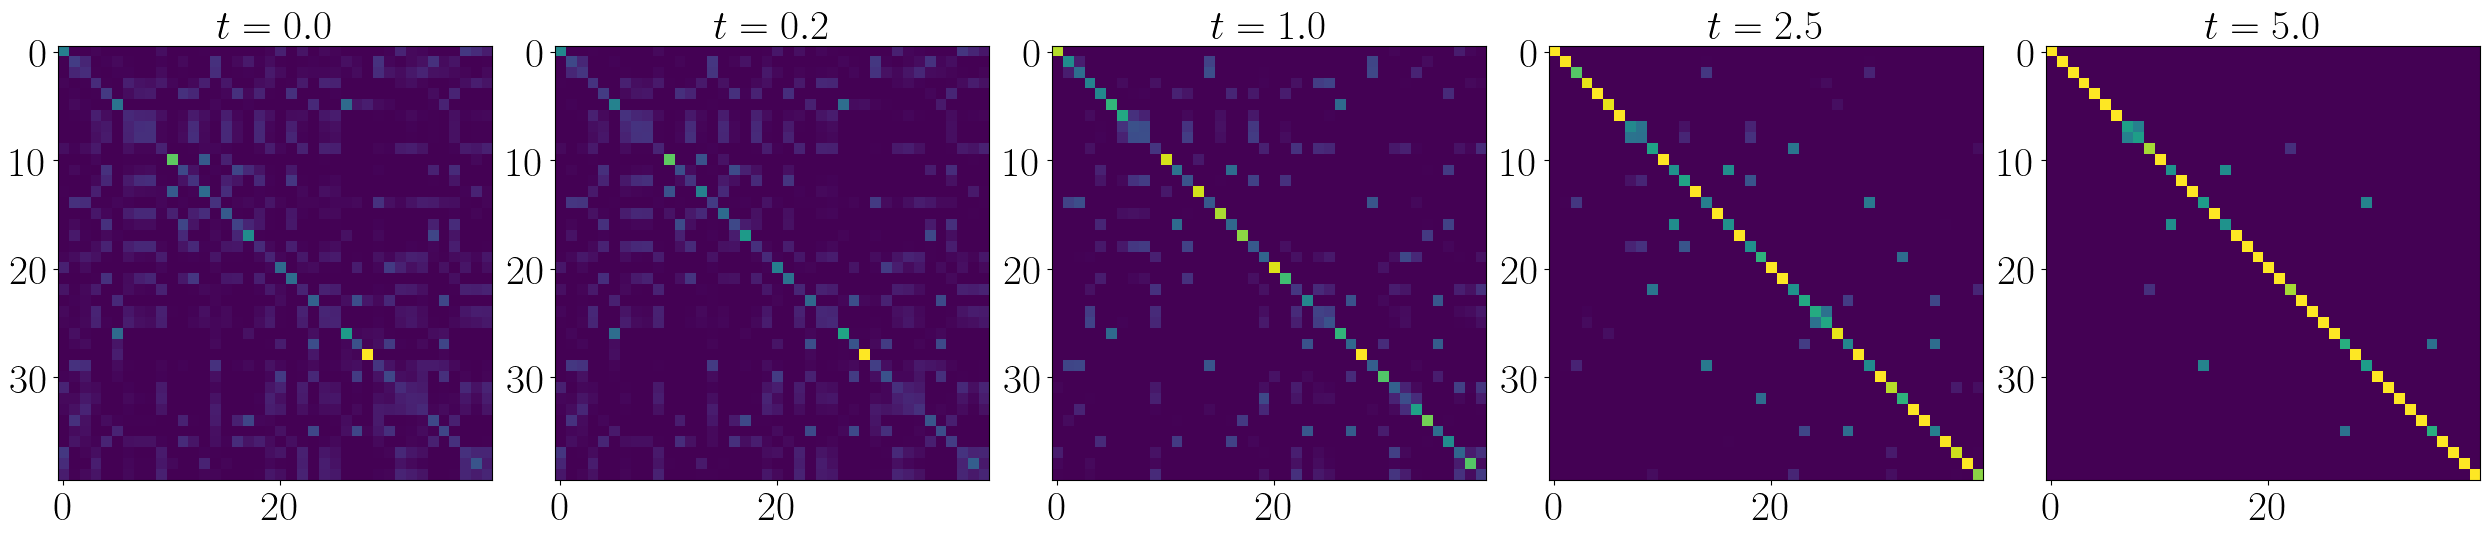

In [134]:
steps = [0, 2, 10, 25, 50]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
for i, step in enumerate(steps):
    axs[i].imshow(self_attn_mat[step], cmap='viridis') 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

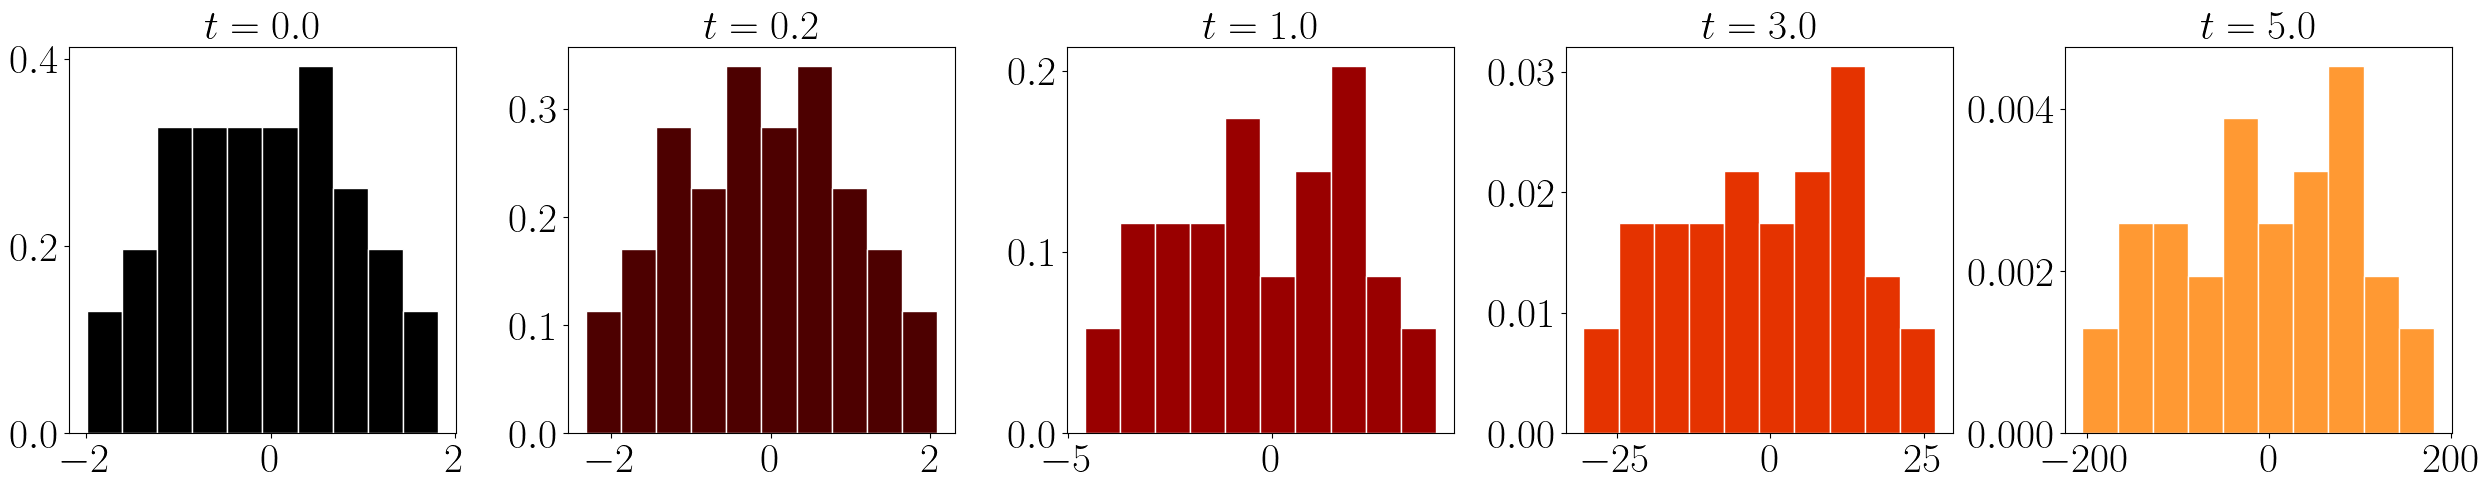

In [140]:
steps = [0, 2, 10, 30, 50]
cmap = plt.get_cmap("gist_heat")

fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
for i, step in enumerate(steps):
    color = cmap(i/len(steps))
    axs[i].hist(x[step][:,0], color=color, edgecolor='white', bins=10, density=True) 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

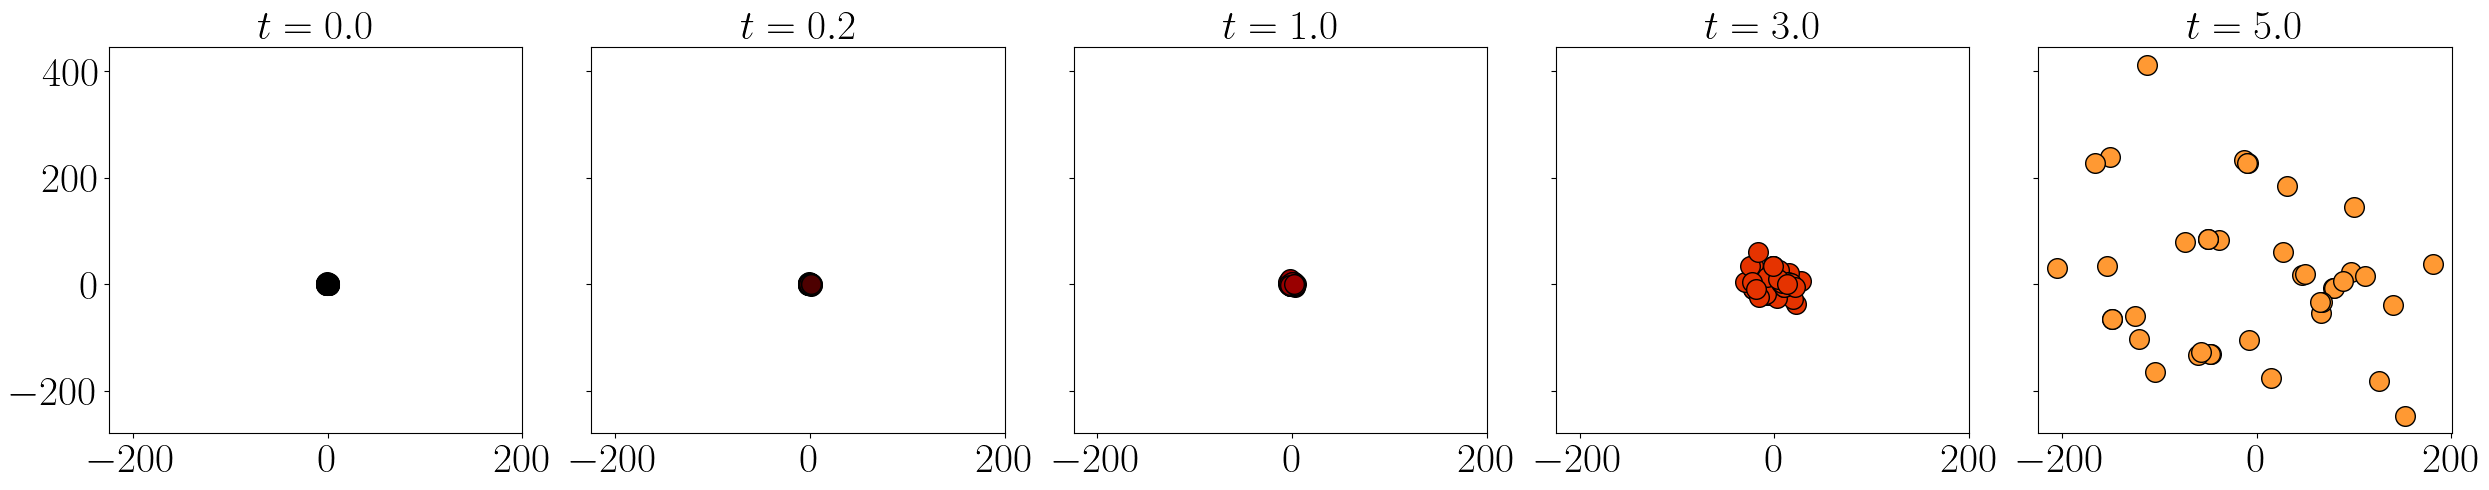

In [139]:
steps = [0, 2, 10, 30, 50]
cmap = plt.get_cmap("gist_heat")

fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5), sharex=True, sharey=True)
for i, step in enumerate(steps):
    color = cmap(i/len(steps))
    axs[i].scatter(x[step][:,0], x[step][:,1], color=color, edgecolor='black', s=200) 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

#### $Q^\top K = I_d$ and $V=-I_d$

$$x_i^{k+1} = x_k^k - \varepsilon \sum_{j=1}^n K^\infty_{ij} x_j^k$$

In [141]:
n, d = 40, 2
A, V = np.eye(d), -np.eye(d)
mu1, mu2 = 0, 0
x0 = np.concatenate((np.random.multivariate_normal(mu1*np.ones(d), np.eye(d), n//2), np.random.multivariate_normal(mu2*np.ones(d), np.eye(d), n//2)))
x, self_attn_mat, spectrum = sinkformer(T, dt, n, d, A, V, x0, checkpoints=None)

100%|██████████| 51/51 [00:00<00:00, 1559.18it/s]


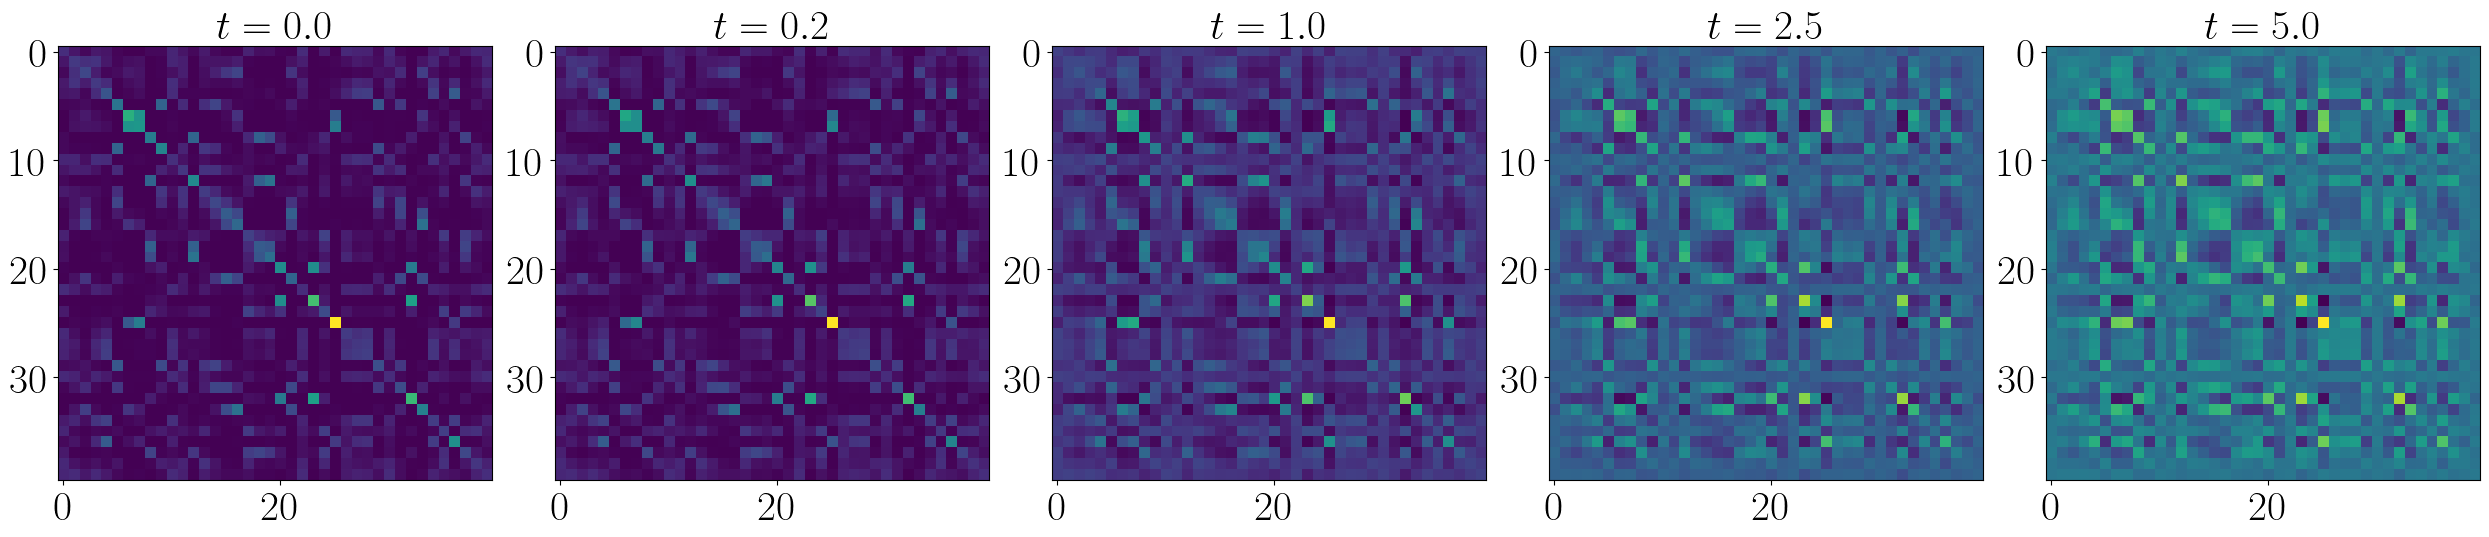

In [142]:
steps = [0, 2, 10, 25, 50]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
for i, step in enumerate(steps):
    axs[i].imshow(self_attn_mat[step], cmap='viridis') 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

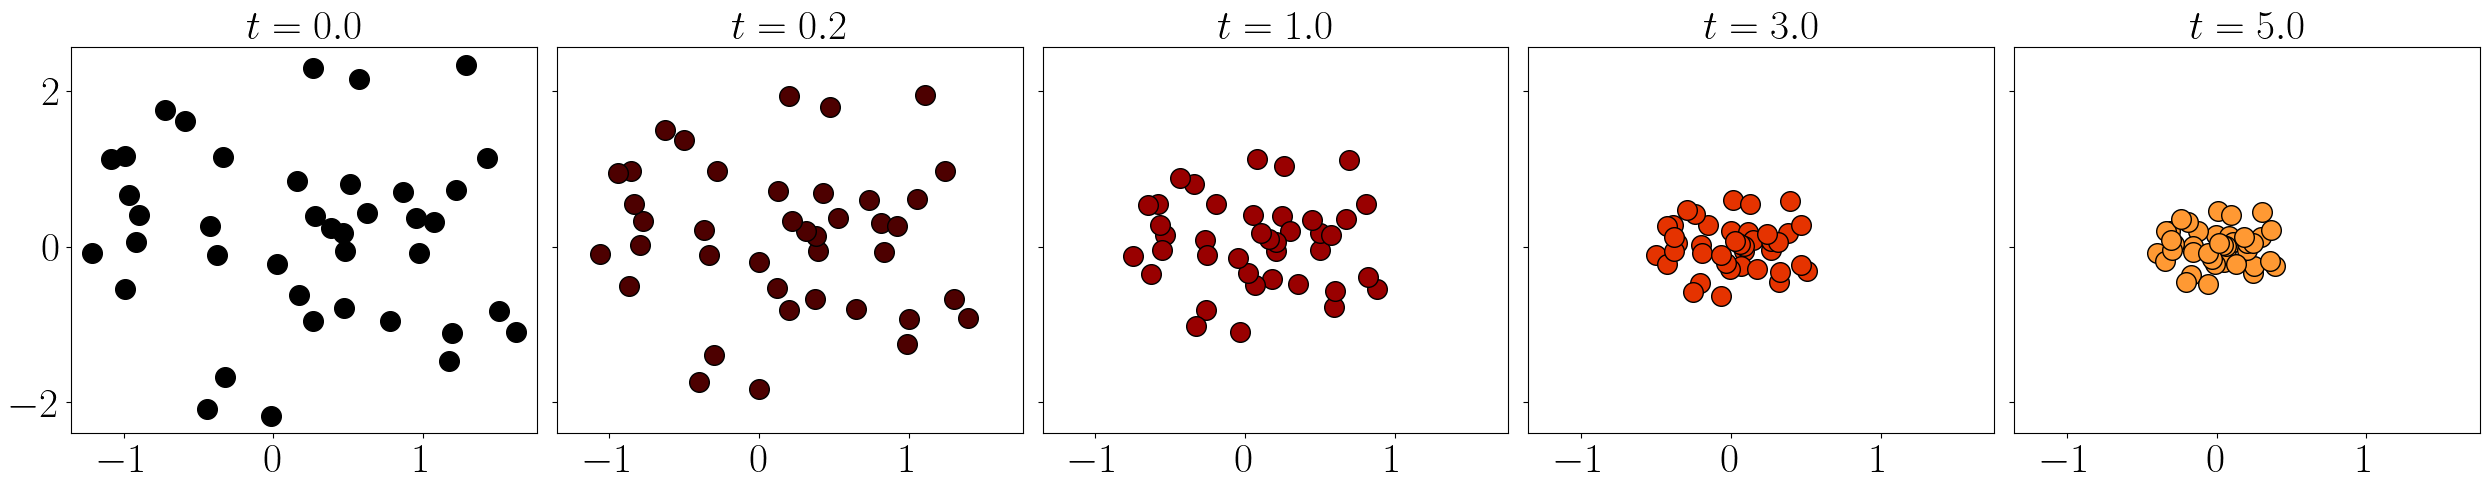

In [143]:
steps = [0, 2, 10, 30, 50]
cmap = plt.get_cmap("gist_heat")

fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5), sharex=True, sharey=True)
for i, step in enumerate(steps):
    color = cmap(i/len(steps))
    axs[i].scatter(x[step][:,0], x[step][:,1], color=color, edgecolor='black', s=200) 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

#### $Q^\top K = I_d$ and $V = I_d$

We consider $n = 40, d = 1$. The self-attention scalars are such that $QK = 1$ and $V=-1$.
The self-attention update is
$$x_i^{k+1} = x_i^k + \varepsilon \frac{\sum_{j=1}^n K^\infty_{\varepsilon\,\,ij} x_j^{k} - x_i^k}{\varepsilon} = \sum_{j=1}^n K^\infty_{\varepsilon\,\,ij} x_j^{k}.$$

In [145]:
n, d = 40, 2
A, V = np.eye(d), np.eye(d)
mu1, mu2 = 0, 0
x0 = np.concatenate((np.random.multivariate_normal(mu1*np.ones(d), np.eye(d), n//2), np.random.multivariate_normal(mu2*np.ones(d), np.eye(d), n//2)))
x, self_attn_mat, spectrum = sinkformer_bandwidth(T, dt, n, d, A, V, x0, checkpoints=None)

  0%|          | 0/51 [00:00<?, ?it/s]/tmp/ipykernel_2583815/1117593939.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  spectrum[checks_count, :] = np.sort(eigenvalues)[::-1]
100%|██████████| 51/51 [00:00<00:00, 130.41it/s]


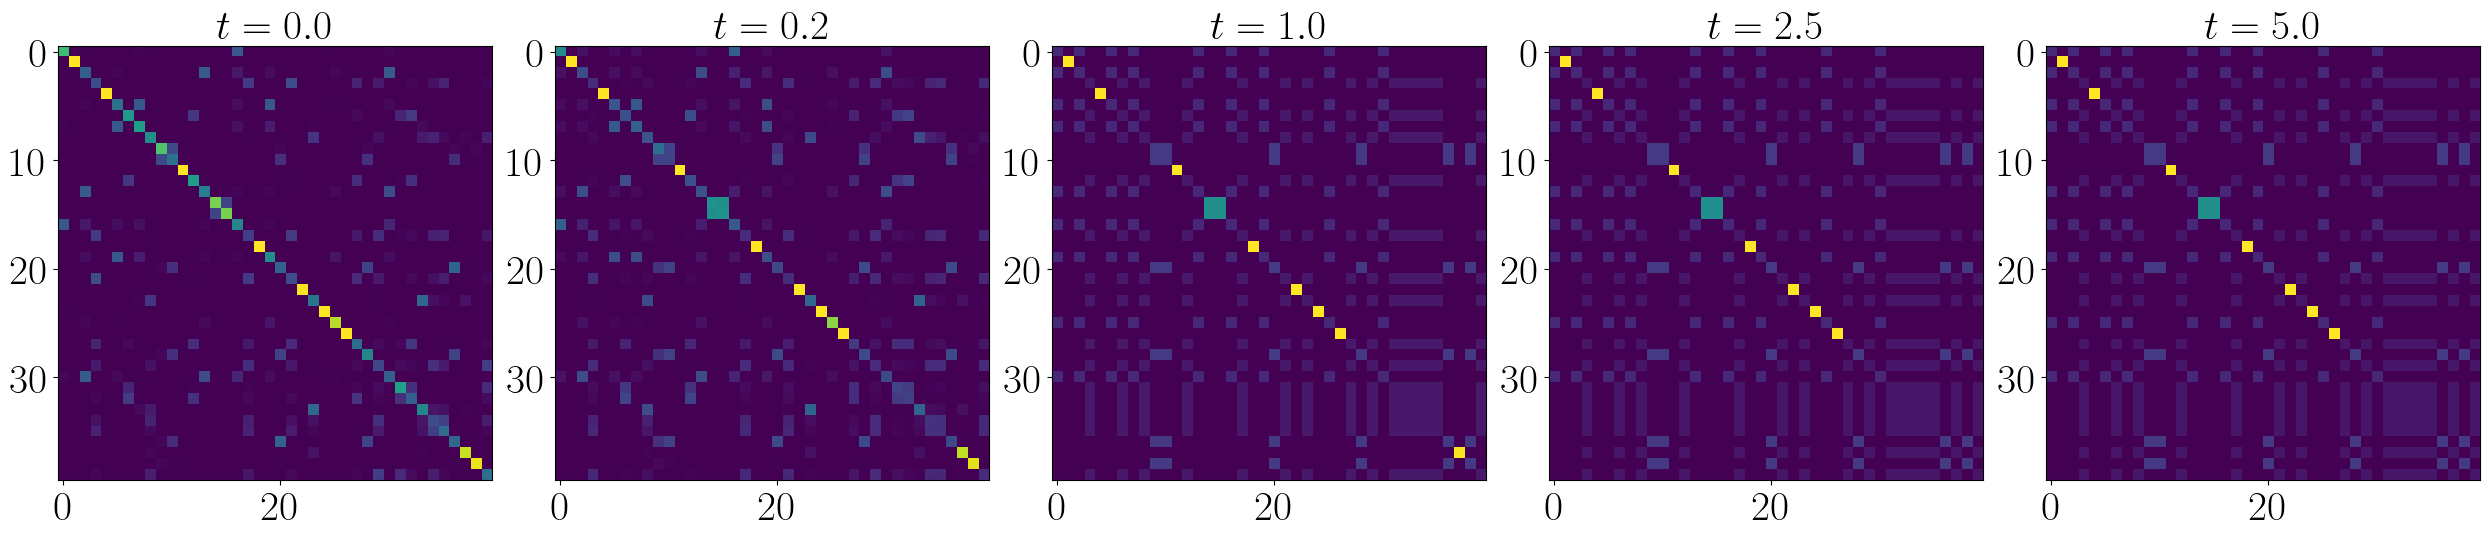

In [146]:
steps = [0, 2, 10, 25, 50]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
for i, step in enumerate(steps):
    axs[i].imshow(self_attn_mat[step], cmap='viridis') 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

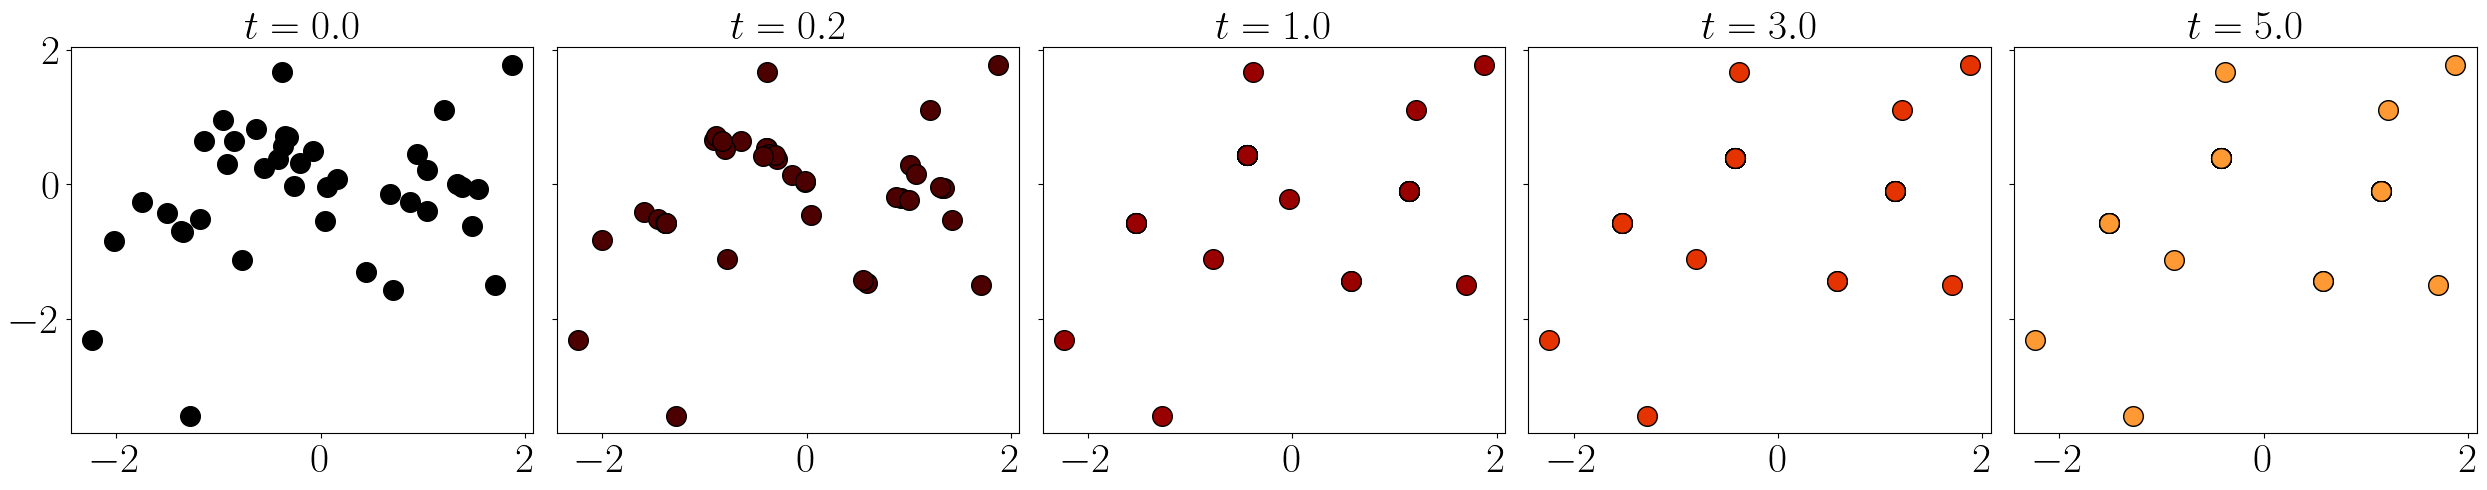

In [147]:
steps = [0, 2, 10, 30, 50]
cmap = plt.get_cmap("gist_heat")

fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5), sharex=True, sharey=True)
for i, step in enumerate(steps):
    color = cmap(i/len(steps))
    axs[i].scatter(x[step][:,0], x[step][:,1], color=color, edgecolor='black', s=200) 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

#### Configuration - 2, $Q^\top K = I_d$ and $V = -I_d$

We consider $n = 40, d = 1$. The self-attention scalars are such that $Q^\top K = 1$ and $V=-1$.
The self-attention update is
$$x_i^{k+1} =   x_i^k + \varepsilon\frac{-\sum_{j=1}^n K^\infty_{\varepsilon \,\, ij} x_j^{k} + x_i^k}{\varepsilon} = 2x_i^k - \sum_{j=1}^n K^\infty_{\varepsilon \,\, ij} x_j^{k}.$$

In [148]:
n, d = 40, 2
A, V = np.eye(d), -np.eye(d)
mu1, mu2 = -2, 2
x0 = np.concatenate((np.random.multivariate_normal(mu1*np.ones(d), np.eye(d), n//2), np.random.multivariate_normal(mu2*np.ones(d), np.eye(d), n//2)))
x, self_attn_mat, spectrum = sinkformer_bandwidth(T, dt, n, d, A, V, x0, checkpoints=None)

100%|██████████| 51/51 [00:00<00:00, 130.95it/s]


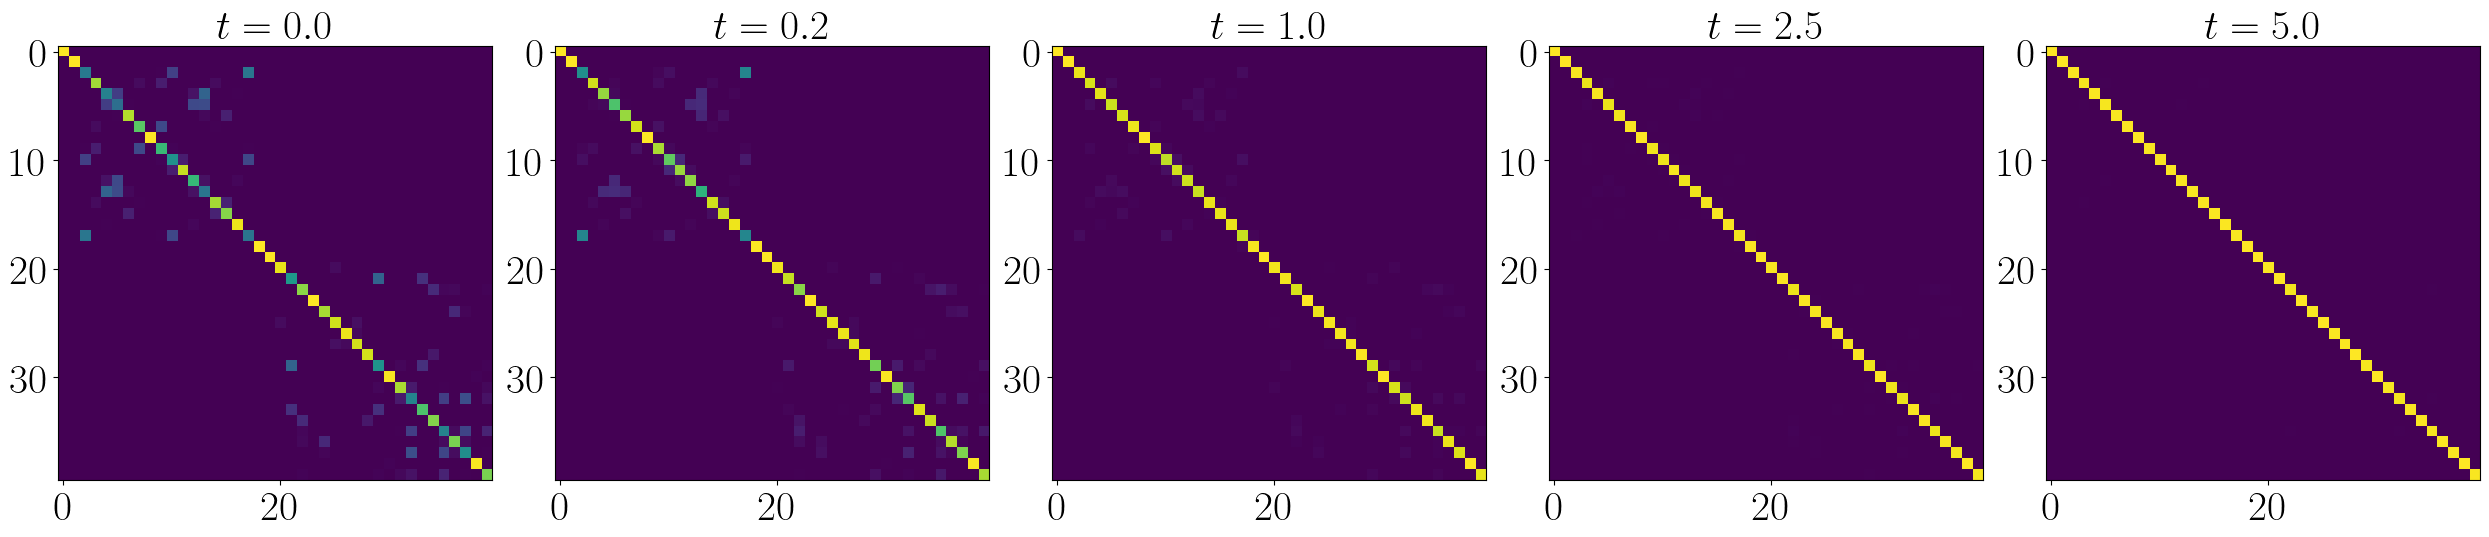

In [149]:
steps = [0, 2, 10, 25, 50]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
for i, step in enumerate(steps):
    axs[i].imshow(self_attn_mat[step], cmap='viridis') 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

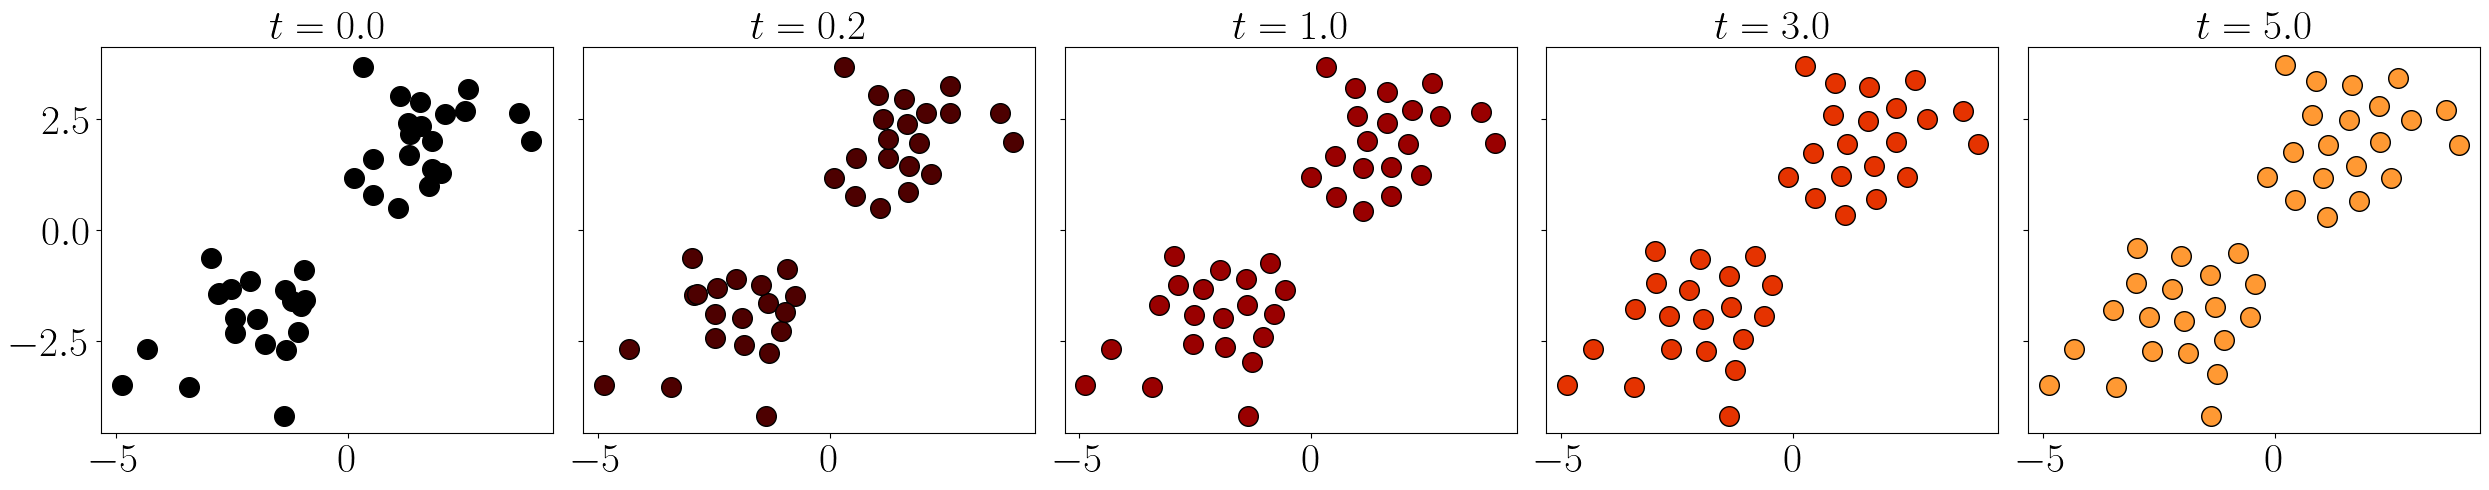

In [150]:
steps = [0, 2, 10, 30, 50]
cmap = plt.get_cmap("gist_heat")

fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5), sharex=True, sharey=True)
for i, step in enumerate(steps):
    color = cmap(i/len(steps))
    axs[i].scatter(x[step][:,0], x[step][:,1], color=color, edgecolor='black', s=200) 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

#### Convex Polytope, $Q^\top K > 0$ and $V = I_d$

In [38]:
n, d = 20, 2
A = np.eye(d)
V = np.eye(d)
x0 = np.random.uniform(low=-5, high=5, size=(n,d))
z, self_attn_mat, spec_gap_list = sinkformer_normalized(T, dt, n, d, A, V, x0)

7it [00:00, 60.76it/s]/tmp/ipykernel_2585076/1156798687.py:41: ComplexWarning: Casting complex values to real discards the imaginary part
  spectrum[checks_count, :] = np.sort(eigenvalues)[::-1]
51it [00:00, 63.78it/s]


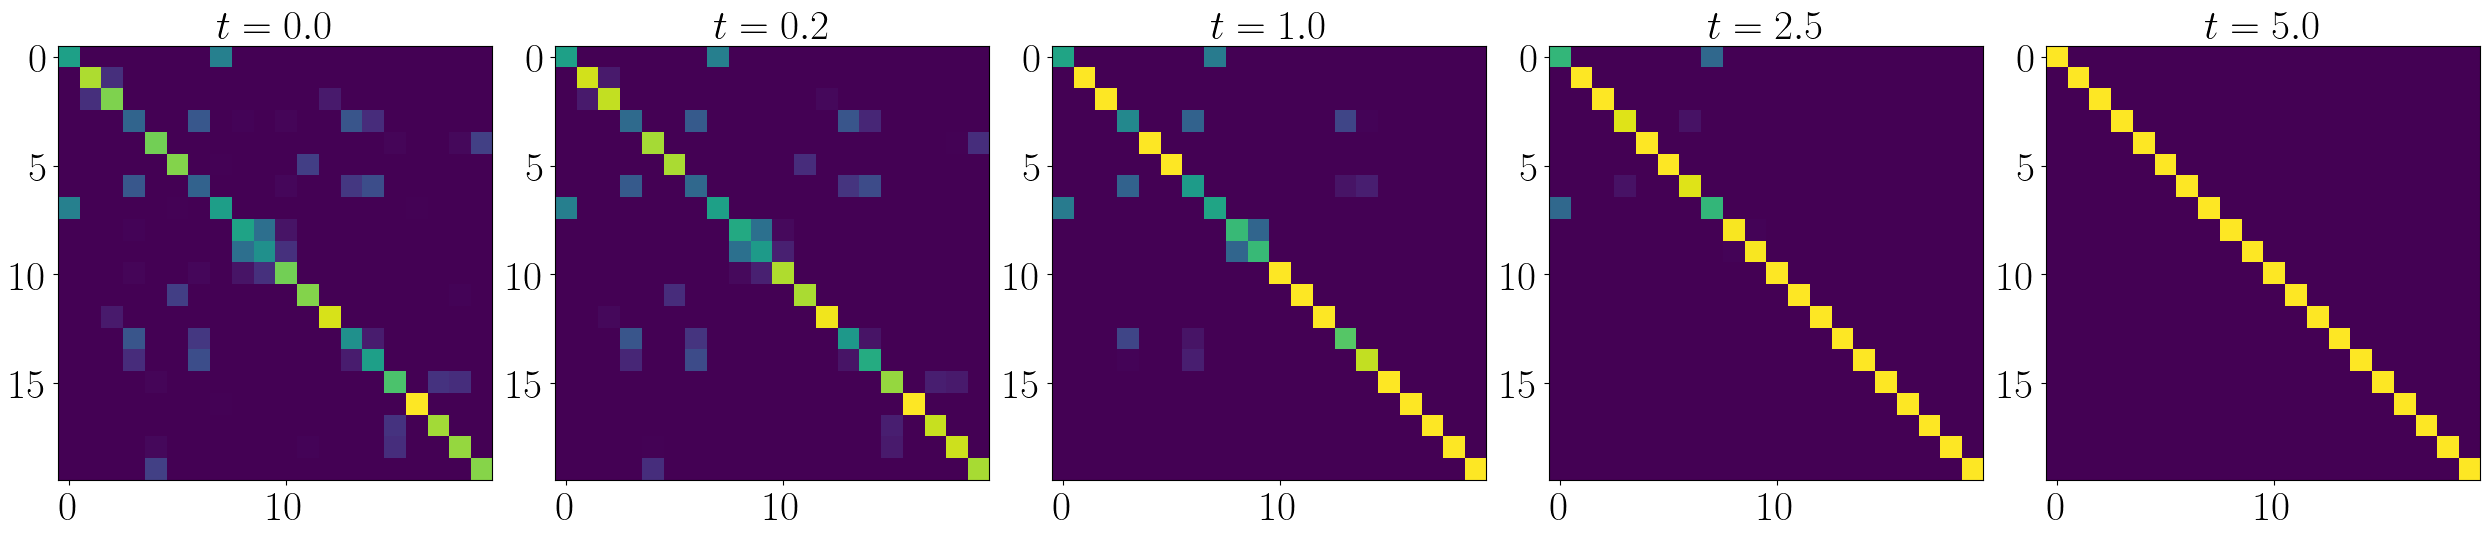

In [39]:
steps = [0, 2, 10, 25, 50]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
for i, step in enumerate(steps):
    axs[i].imshow(self_attn_mat[step], cmap='viridis') 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

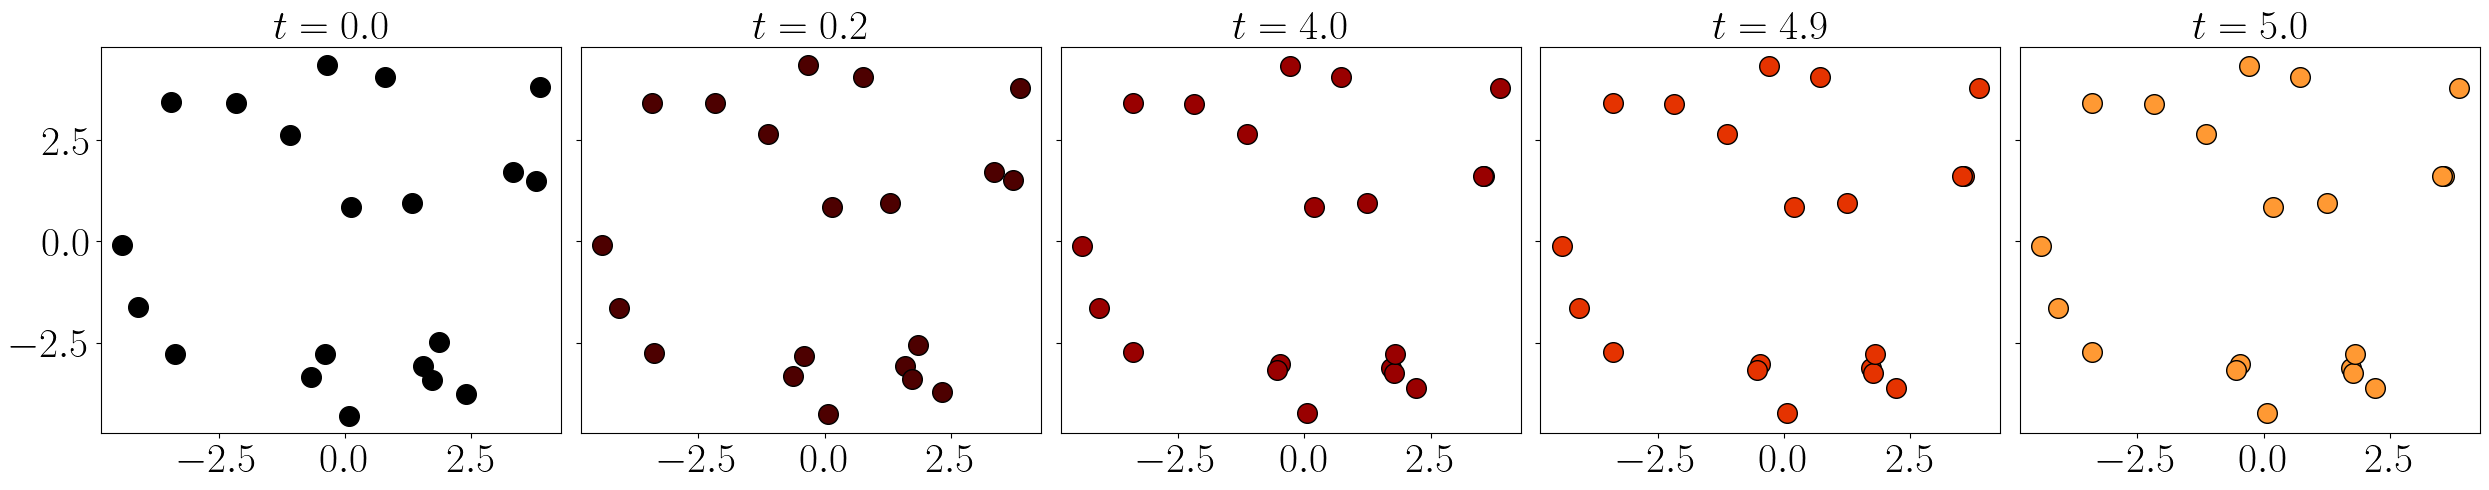

In [40]:
steps = [0, 2, 40, 49, 50]
cmap = plt.get_cmap("gist_heat")

fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5), sharex=True, sharey=True)
for i, step in enumerate(steps):
    color = cmap(i/len(steps))
    axs[i].scatter(z[step][:,0], z[step][:,1], color=color, edgecolor='black', s=200) 
    axs[i].set_title(f"$t = {step/10}$")
plt.tight_layout()
plt.show()

IndexError: index 100 is out of bounds for axis 0 with size 51

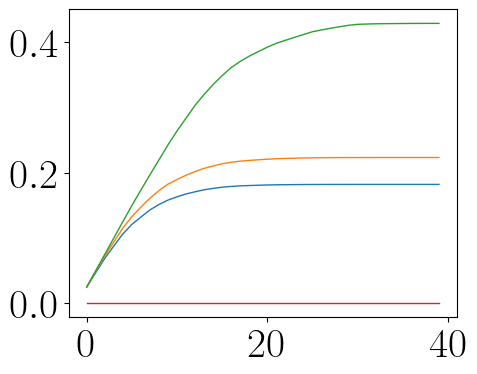

In [23]:
steps = [0, 2, 10, 50, 100, 200]
cmap = plt.get_cmap("gist_heat")
plt.figure(figsize=(5,4))
for i in range(len(steps)):
    color = cmap(i/len(steps))
    plt.plot(np.arange(n), np.cumsum(spec_gap_list[steps[i]]), linewidth=1, label=f"$t = {steps[i]/10}$")

plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.8), ncol=3)
# plt.tight_layout()
plt.show()


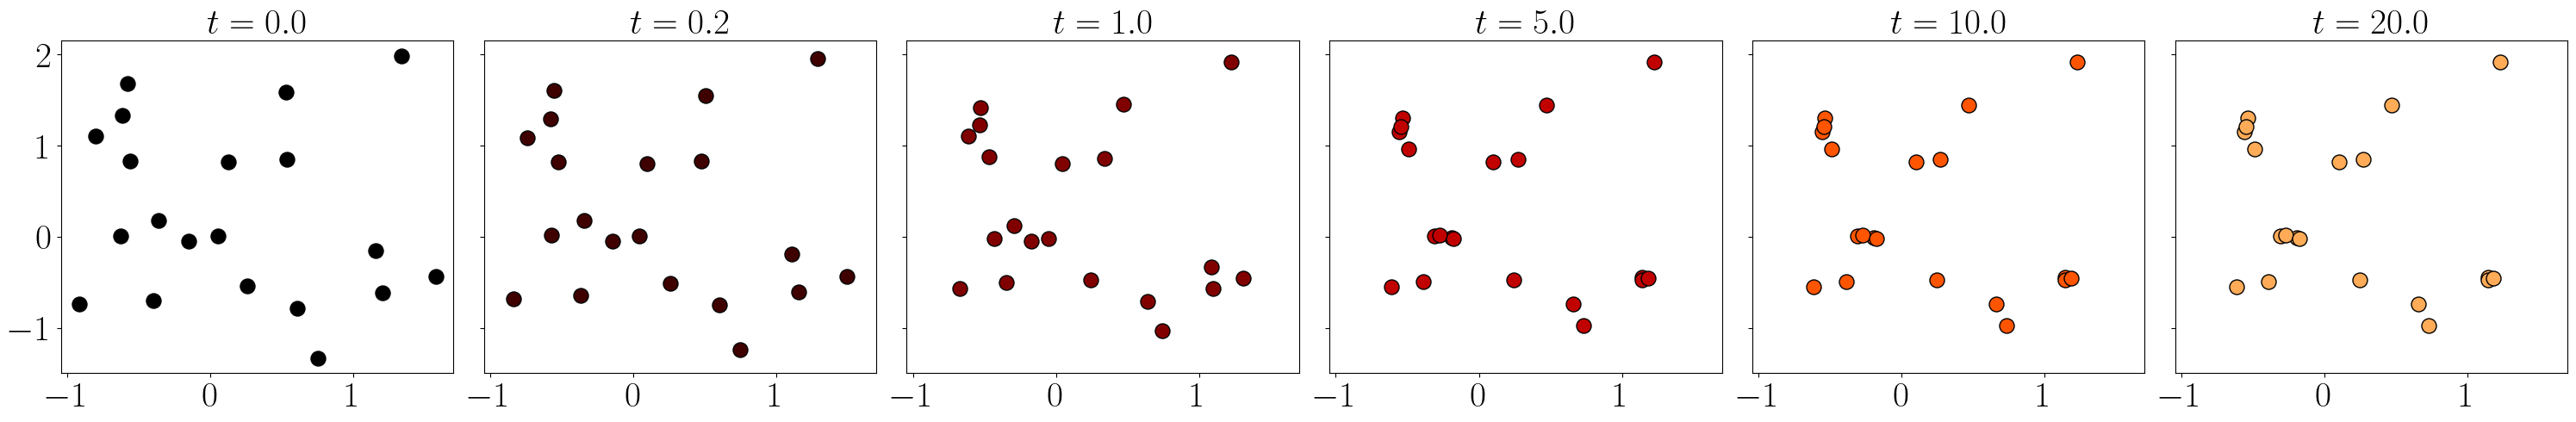

In [295]:
steps = [0, 2, 10, 50, 100, 200]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5), sharey=True, sharex=True)
cmap = plt.get_cmap("gist_heat")

for i in range(len(steps)):

    color = cmap(i/len(steps))
    axs[i].scatter(z[:, steps[i], 0], z[:, steps[i], 1], color=color, edgecolor='black', s=150)
    axs[i].set_title(f"$t = {steps[i]/10}$")
    # axs[i].set_xlim(-5, 5)
    # axs[i].set_ylim(0, .5)

plt.tight_layout()
plt.show()

#### Convex Polytope, $Q^\top K > 0$ and $V = -I_d$

In [303]:
T = 20
eps = 0.1
n = 20
d = 2
A = np.eye(d)
V = -np.eye(d)
X = np.random.normal(size=(n,d))
z, self_attn_mat, spec_gap_list = transformer(T, eps, n, d, A, V, X)

201it [00:03, 53.25it/s]


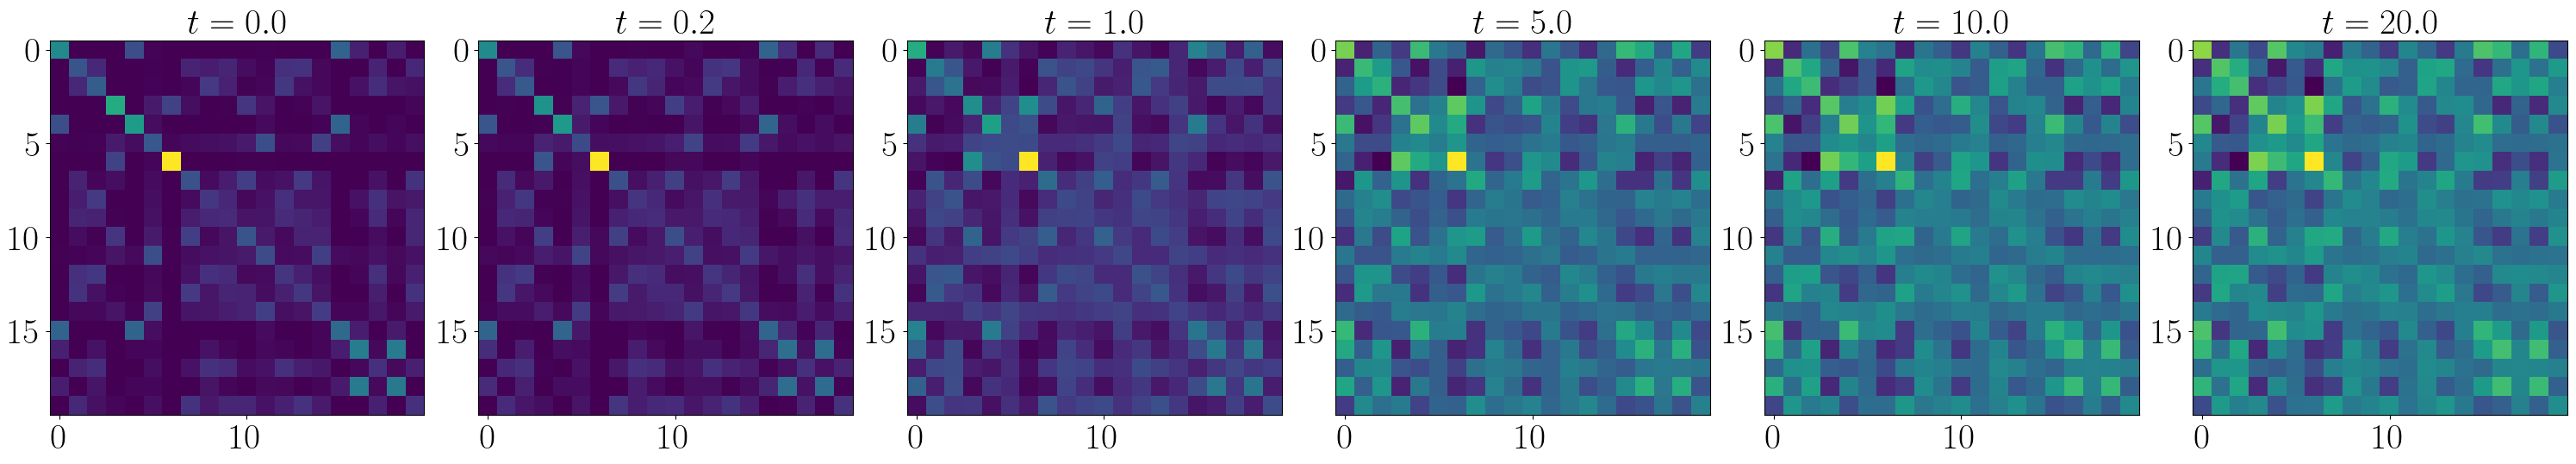

In [304]:
steps = [0, 2, 10, 50, 100, 200]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
for i in range(len(steps)):
    step = steps[i]

    axs[i].imshow(self_attn_mat[step], cmap='viridis')
    axs[i].set_title(f"$t = {step/10}$")

plt.tight_layout()
plt.show()

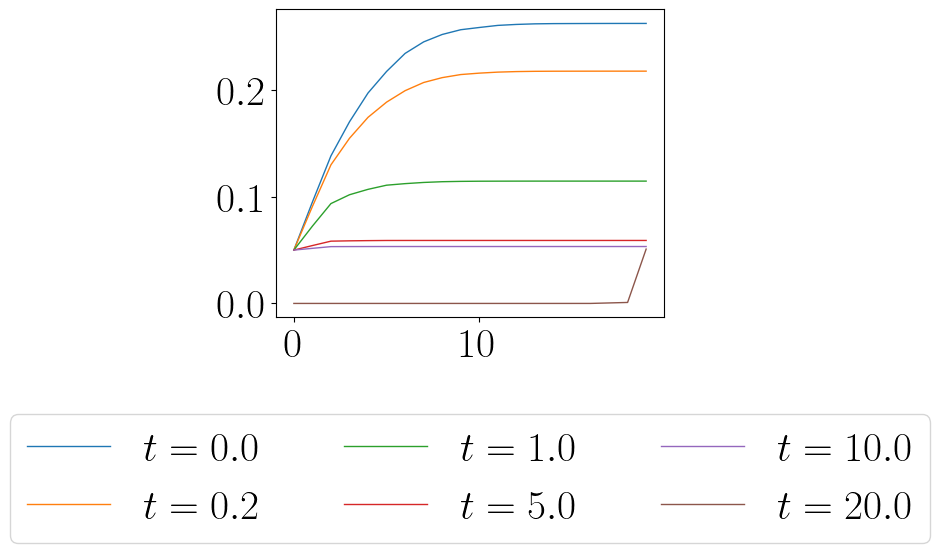

In [305]:
steps = [0, 2, 10, 50, 100, 200]
cmap = plt.get_cmap("gist_heat")
plt.figure(figsize=(5,4))
for i in range(len(steps)):
    color = cmap(i/len(steps))
    plt.plot(np.arange(n), np.cumsum(spec_gap_list[steps[i]]), linewidth=1, label=f"$t = {steps[i]/10}$")

plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.8), ncol=3)
# plt.tight_layout()
plt.show()


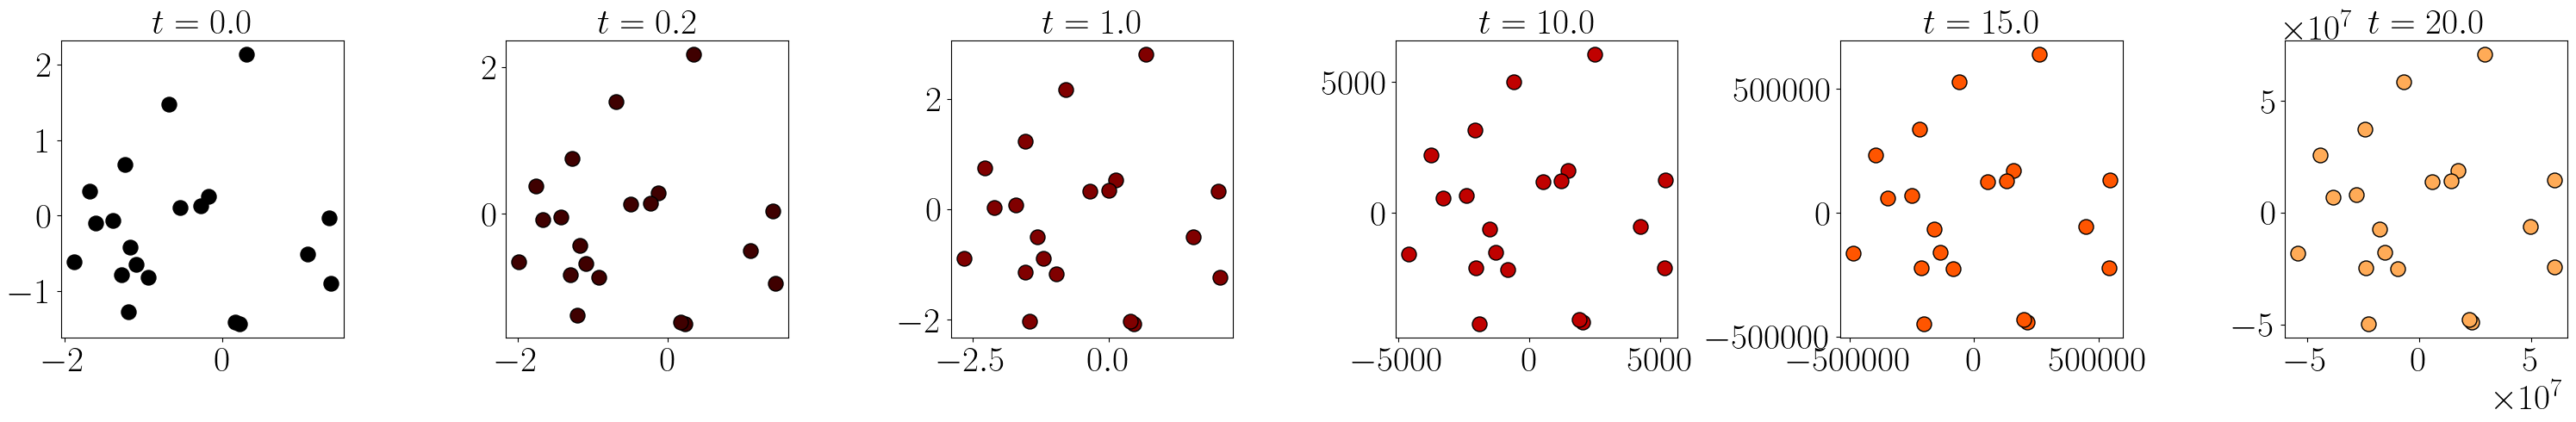

In [311]:
steps = [0, 2, 10, 100, 150, 200]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
cmap = plt.get_cmap("gist_heat")

for i in range(len(steps)):

    color = cmap(i/len(steps))
    axs[i].scatter(z[:, steps[i], 0], z[:, steps[i], 1], color=color, edgecolor='black', s=150)
    axs[i].set_title(f"$t = {steps[i]/10}$")
plt.tight_layout()
plt.show()

#### Convex Polytope, $Q^\top K > 0$ and $\lambda(V) > 0$

In [314]:
T = 20
eps = 0.1
n = 20
d = 2
A = np.eye(d)
V = np.random.rand(d, d)
V = np.abs(V)               # Perron Frobenius
print("Eigenvalues of V:")
print(np.linalg.eigvals(V))
X = np.random.normal(size=(n,d))
z, self_attn_mat, spec_gap_list = transformer(T, eps, n, d, A, V, X)

Eigenvalues of V:
[ 1.18478611 -0.01953048]


201it [00:20,  9.64it/s]


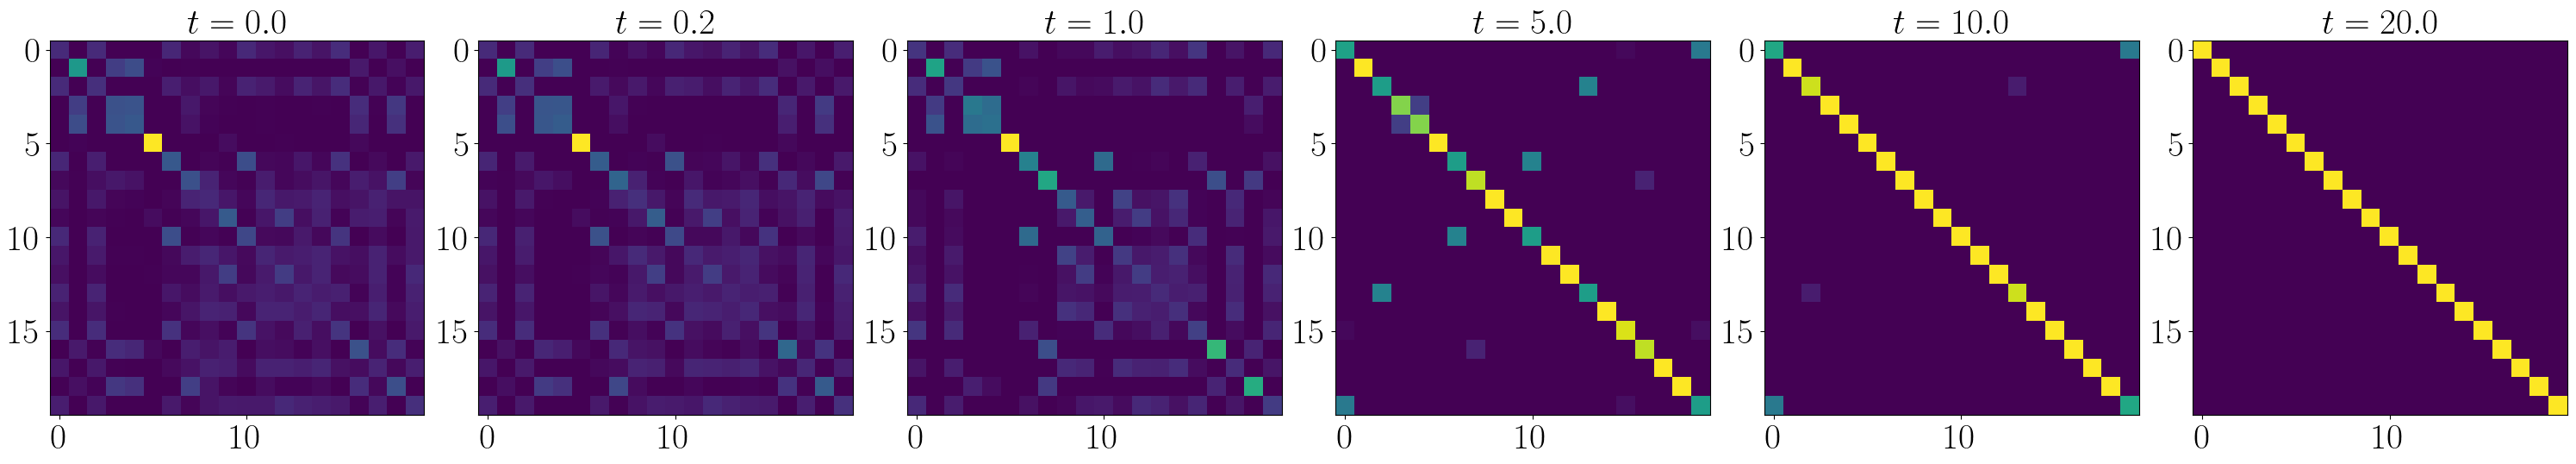

In [315]:
steps = [0, 2, 10, 50, 100, 200]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
for i in range(len(steps)):
    step = steps[i]

    axs[i].imshow(self_attn_mat[step], cmap='viridis')
    axs[i].set_title(f"$t = {step/10}$")

plt.tight_layout()
plt.show()

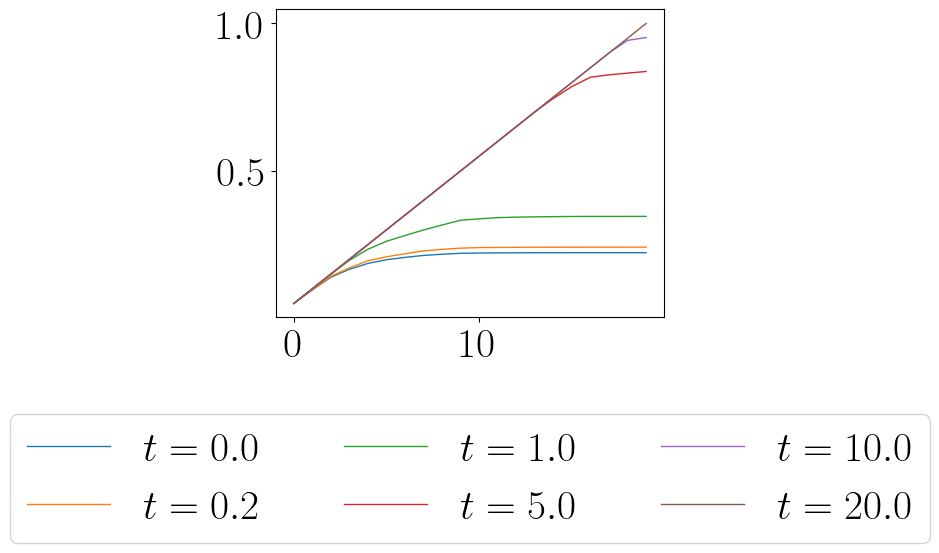

In [316]:
steps = [0, 2, 10, 50, 100, 200]
cmap = plt.get_cmap("gist_heat")
plt.figure(figsize=(5,4))
for i in range(len(steps)):
    color = cmap(i/len(steps))
    plt.plot(np.arange(n), np.cumsum(spec_gap_list[steps[i]]), linewidth=1, label=f"$t = {steps[i]/10}$")

plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.8), ncol=3)
# plt.tight_layout()
plt.show()


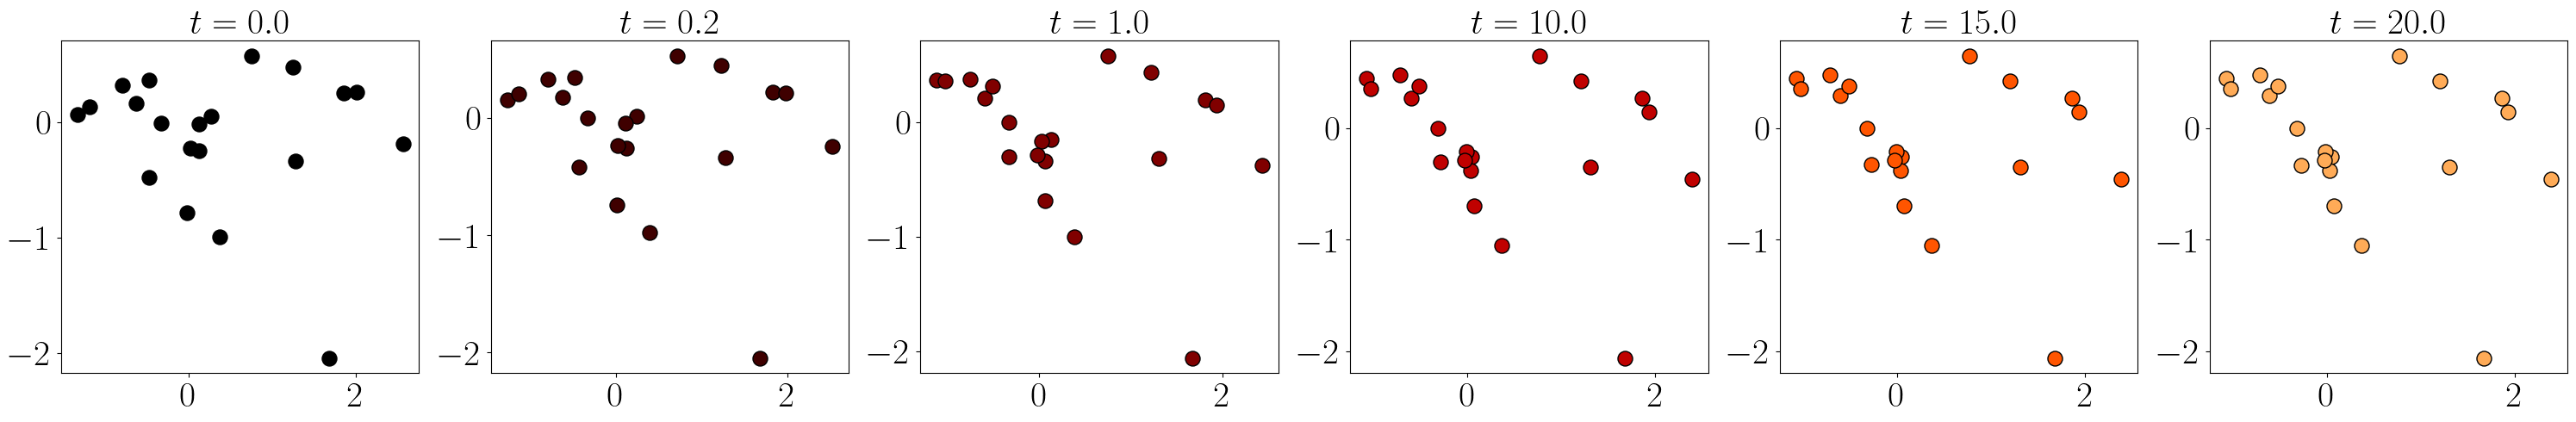

In [317]:
steps = [0, 2, 10, 100, 150, 200]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
cmap = plt.get_cmap("gist_heat")

for i in range(len(steps)):

    color = cmap(i/len(steps))
    axs[i].scatter(z[:, steps[i], 0], z[:, steps[i], 1], color=color, edgecolor='black', s=150)
    axs[i].set_title(f"$t = {steps[i]/10}$")
plt.tight_layout()
plt.show()

#### Convex Polytope, $Q^\top K > 0$ and $V$ is paranormal


In [318]:
T = 20
eps = 0.1
n = 20
d = 2
A = np.eye(d)
V = np.eye(d)
V[-1][-1] = -0.5        # Perron Frobenius
print("Eigenvalues of V:")
print(np.linalg.eigvals(V))
X = np.random.normal(size=(n,d))
z, self_attn_mat, spec_gap_list = transformer(T, eps, n, d, A, V, X)

Eigenvalues of V:
[ 1.  -0.5]


65it [00:01, 51.68it/s]/tmp/ipykernel_2570373/1851040955.py:36: ComplexWarning: Casting complex values to real discards the imaginary part
  spec_gap_list[l] = np.sort(eigenvalues)[::-1]
201it [00:03, 51.27it/s]


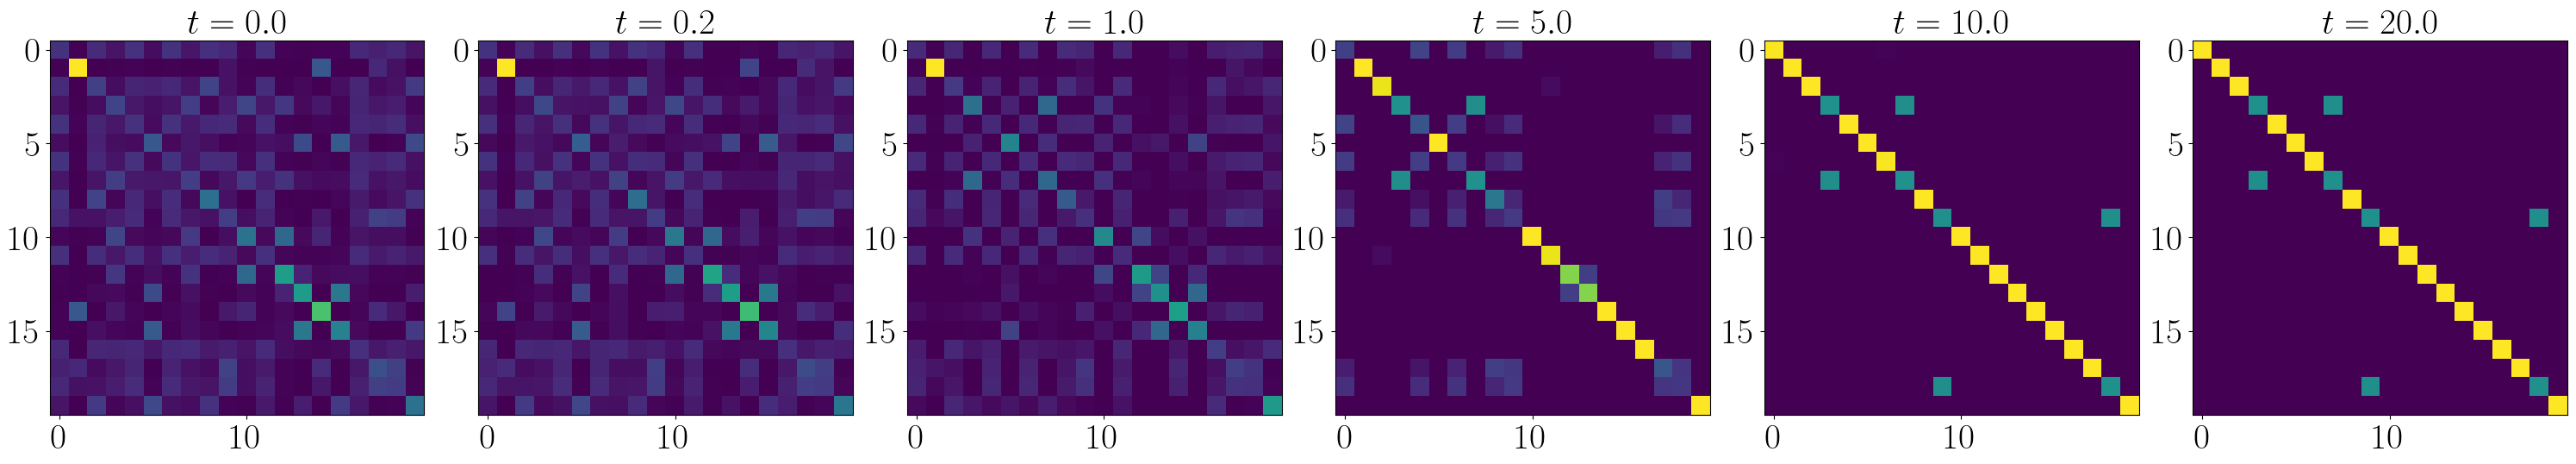

In [319]:
steps = [0, 2, 10, 50, 100, 200]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
for i in range(len(steps)):
    step = steps[i]

    axs[i].imshow(self_attn_mat[step], cmap='viridis')
    axs[i].set_title(f"$t = {step/10}$")

plt.tight_layout()
plt.show()

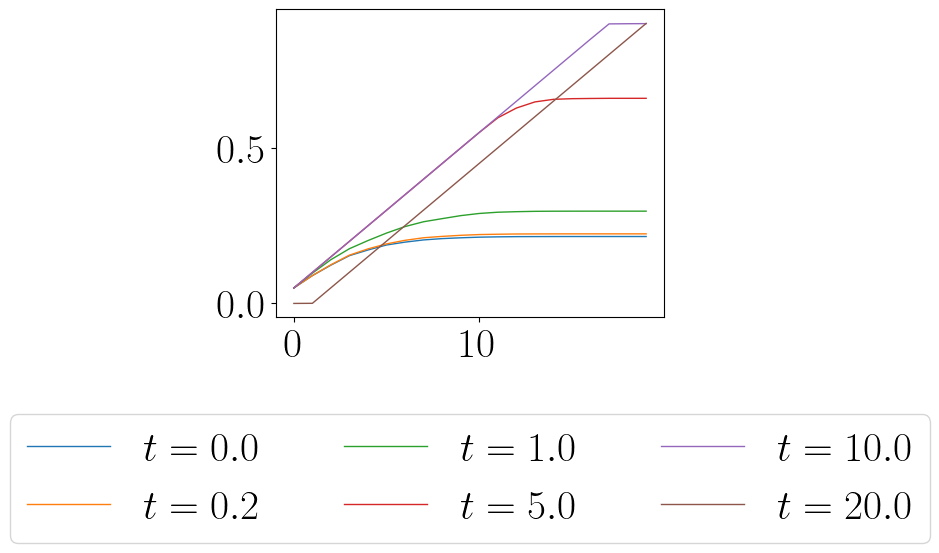

In [320]:
steps = [0, 2, 10, 50, 100, 200]
cmap = plt.get_cmap("gist_heat")
plt.figure(figsize=(5,4))
for i in range(len(steps)):
    color = cmap(i/len(steps))
    plt.plot(np.arange(n), np.cumsum(spec_gap_list[steps[i]]), linewidth=1, label=f"$t = {steps[i]/10}$")

plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.8), ncol=3)
# plt.tight_layout()
plt.show()


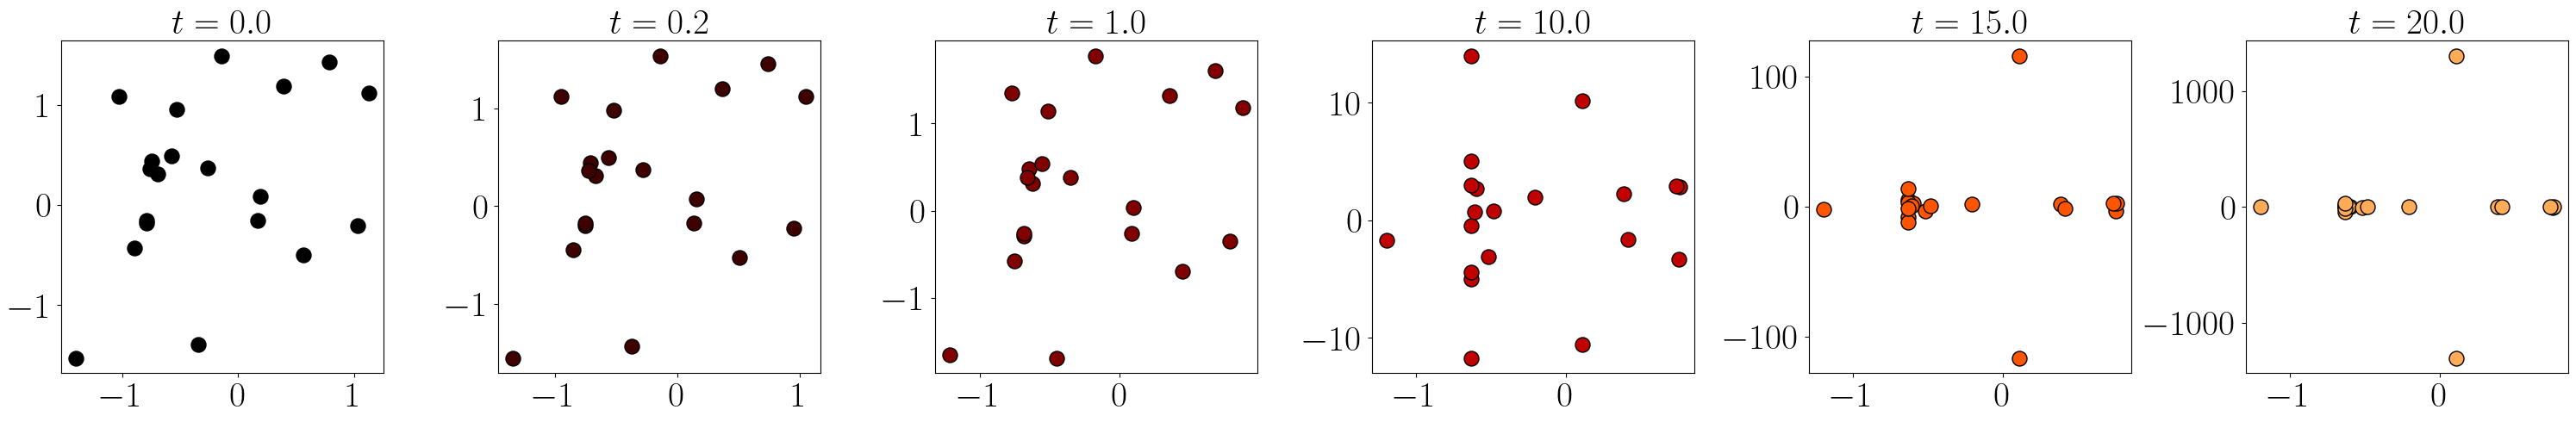

In [321]:
steps = [0, 2, 10, 100, 150, 200]
fig, axs = plt.subplots(1, len(steps), figsize=(5*(len(steps)), 5))
cmap = plt.get_cmap("gist_heat")

for i in range(len(steps)):

    color = cmap(i/len(steps))
    axs[i].scatter(z[:, steps[i], 0], z[:, steps[i], 1], color=color, edgecolor='black', s=150)
    axs[i].set_title(f"$t = {steps[i]/10}$")
plt.tight_layout()
plt.show()